# Face Image Classification Based on Convolutional Neural Network using Pytorch
- This notebook is designed to introduce image classification using a Convolutional Neural Network (CNN) with the PyTorch library.
- The dataset used in this example consists of gray color  face images of three individuals, representing three classes.
- In this notebook, we will learn how to load and prepare the dataset, construct simple CNN architecture, training model, and evaluation assessment.


**Ying-Nong Chen's Lab: https://sites.google.com/view/yingnongchen**

## Dataset Preparation
- This notebook will use GPU (so make sure to turn on GPU in the Colab: --> Runtime --> Change runtime type --> Select T4 GPU)
- This notebook will use the image dataset saved in our Google Drive (Please download the example of dataset used from this following link:
https://drive.google.com/drive/folders/1qeoch3d4ikXnqxojebBgE5UudNcyEK5W?usp=sharing )

In [ ]:
## Import used libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
# Set random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [ ]:
# check whether used GPU or CPU and set to device
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    device = torch.device("mps")
print(device)

cuda


### Load Image Dataset from Google Drive
- Please firstly download the example of Face Dataset and placed into your Google Drive
- Connect your Google Drive for this notebook

In [ ]:
## Mounting to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

#### Load image dataset

In [ ]:
# Define path for our Face folder
data_dir = "/content/drive/MyDrive/Invited Fo Guang Univ/Face_Datasets" # change it according with Face folder path

# Define transformation that used to transform our image data into tensor
# Using transform function from torchvision Library
# Resize image to get bigger input shape (usefull for more advance model)
transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize image shape
    transforms.Grayscale(), # Transform image to grayscale
    transforms.ToTensor(),
])

# Finally we can load our dataset by using function datasets from torchvisison Library
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(dataset)

Dataset ImageFolder
    Number of datapoints: 30
    Root location: /content/drive/MyDrive/Invited Fo Guang Univ/Face_Datasets
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               Grayscale(num_output_channels=1)
               ToTensor()
           )


We have three indiviudal face data (three classes). Each folder contains of 10 images, so we will hae 30 datapoints.

#### Split dataset become training and testing set
- We want to split our dataset becom 50% for training and 50% for testing
- Note: we needs balance dataset for each class, so the umber of training of each class is 5 images and for testing also 5 images

In [ ]:
# First we nee to extract indices and labels from the dataset
indices = list(range(len(dataset)))  # List of all indices
labels = [dataset[i][1] for i in indices]  # Extract labels

# We use train_test_split from Sklearn Library
# to perform stratified split (50% train, 50% test)
# this procedure will makesure we have balance split data for each class
train_indices, test_indices = train_test_split(
    indices, test_size=0.5, stratify=labels, random_state=seed
)

# Produce the train and test dataset based on the image indices
train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

print('Number of images in the training dataset:', len(train_dataset))
print('Number of images in the testing dataset:', len(test_dataset))

Number of images in the training dataset: 15
Number of images in the testing dataset: 15


In [ ]:
# Check the class distribution
def count_classes(dataset):
    labels = [dataset[i][1] for i in range(len(dataset))]
    class_counts = np.bincount(labels)
    return {f"Class {i}": int(count) for i, count in enumerate(class_counts)}

print("Training class distribution:", count_classes(train_dataset))
print("Testing class distribution:", count_classes(test_dataset))

Training class distribution: {'Class 0': 5, 'Class 1': 5, 'Class 2': 5}
Testing class distribution: {'Class 0': 5, 'Class 1': 5, 'Class 2': 5}


#### Create DataLoaders
After we successfully produce the training and testing daataset, we need to efficiently feed the data into our model for training and evaluation.

In [ ]:
# Create DataLoader for both training and testing data
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

print(f"Shape of the images in the training dataset: {train_loader.dataset[0][0].shape}")
print(f"Shape of the images in the testing dataset: {test_loader.dataset[0][0].shape}")

Shape of the images in the training dataset: torch.Size([1, 64, 64])
Shape of the images in the testing dataset: torch.Size([1, 64, 64])


#### Visualize example of dataset

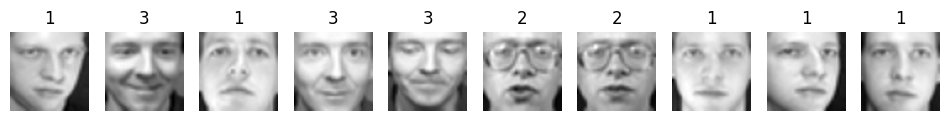

In [ ]:
# Define class number
classes = ('1', '2', '3')

fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    image = train_loader.dataset[i][0].squeeze(0) # For grayscale image
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(classes[train_loader.dataset[i][1]])
    axes[i].axis('off')
plt.show()

## Construct Simple CNN Model
- In this step, we will construct simple CNN model by using Pytorch Library
- Our simple CNN model will have: 2D Conv followed by ReLu -> Max Pooling Layer -> another 2D Conv followed by ReLu -> and another Max Pooling Layer -> reshape layer -> fully connected layer

In [ ]:
# To construct the CNN model using Pytroch we need define the class model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3, in_channels= 1):
        """
        In this part we will define all layers of our CNN model
        """
        super(SimpleCNN, self).__init__()

        # First convolutional layer: 1 input channel, 8 output feature maps, 3x3 kernel, stride 1, padding 1
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, stride=1, padding=1)
        # Define Max Pooling layer: 2x2 kernel size and stride 2
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Second convolutional layer: 8 input channel, 16 output feature maps, 3x3 kernel, stride 1, padding 1
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        # Define Max Pooling layer: 2x2 kernel size and stride 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Fully connected layer: 16*16*16 input features (after two 2x2 poolings), 3 output features (num_classes)
        self.fc1 = nn.Linear(16 * 16 * 16 , num_classes)

    def forward(self, x):
        """
        In this part we will define the forward pass of the CNN model
        """
        x = F.relu(self.conv1(x))  # Apply first convolution followed by ReLU activation
        x = self.maxpool1(x)       # Apply max pooling 1
        x = F.relu(self.conv2(x))  # Apply second convolution followed by ReLU activation
        x = self.maxpool2(x)       # Apply max pooling 2
        x = x.reshape(x.shape[0], -1)  # Flatten the tensor
        x = self.fc1(x) # Apply fully connected layer
        # x = F.softmax(x, dim=1)  # Apply softmax activation (dim=1 for class probabilities)

        return x

In [ ]:
# Initialize model
model = SimpleCNN(num_classes=3,  in_channels=1)
model.to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=3, bias=True)
)


In [ ]:
# Print total number of trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of trainable parameters: {trainable_params}')

Total number of trainable parameters: 13539


In [ ]:
from torchsummary import summary
summary(model, (1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 64, 64]              80
         MaxPool2d-2            [-1, 8, 32, 32]               0
            Conv2d-3           [-1, 16, 32, 32]           1,168
         MaxPool2d-4           [-1, 16, 16, 16]               0
            Linear-5                    [-1, 3]          12,291
Total params: 13,539
Trainable params: 13,539
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.47
Params size (MB): 0.05
Estimated Total Size (MB): 0.54
----------------------------------------------------------------


#### Define Loss and Optimizer parameters

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss() # Since our task is image classification, we use Cross entropy as or loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # we use Adam as our optimizer

## Model training process
- After we have train dataset and constructed our CNN model the next steps is to train the CNN model by using our train data

In [ ]:
# List to track loss values for each epoch
losses = []

epochs = 10 # Define total number of epochs
for epoch in range(epochs):

    running_loss = 0.0
    for i, (images, targets) in enumerate(train_loader):
        # Move data and targets to the device (GPU/CPU)
        images = images.to(device)
        targets = targets.to(device)

        # -- Forward pass:
        # clears old gradients from the last step
        optimizer.zero_grad()

        # train the images
        outputs = model(images)

        #calculate the loss given the ouputs and the classes
        loss = criterion(outputs, targets)

        # -- Backward pass:
        # compute the loss of every parameter
        loss.backward()

        # apply the optimizer and it's parameters
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

print('Finished Training')

Epoch 1, Loss: 1.1676
Epoch 2, Loss: 1.0453
Epoch 3, Loss: 1.0029
Epoch 4, Loss: 0.9159
Epoch 5, Loss: 0.7943
Epoch 6, Loss: 0.6653
Epoch 7, Loss: 0.5329
Epoch 8, Loss: 0.3797
Epoch 9, Loss: 0.2256
Epoch 10, Loss: 0.1652
Finished Training


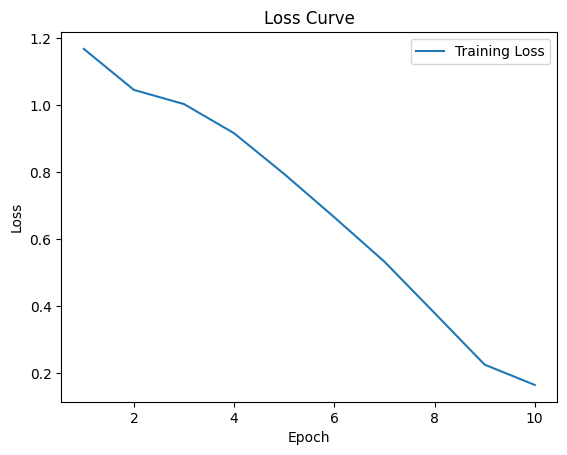

In [ ]:
# Plot loss curve
plt.plot(range(1, epochs + 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

## Model Evaluation Assessment

In [ ]:
# Firstly define the variable correct and total to calculate accuracy
correct = 0
total = 0

model.eval()  # Set the model to evaluation mode

with torch.no_grad(): # for the inference process, we need to disable gradient calculation
    for (images, targets) in test_loader:
        # Move data and targets to the device (GPU/CPU)
        images = images.to(device)
        targets = targets.to(device)

        # Compute the model output
        outputs = model(images)

        # Get the index of the max log-probability
        _, predicted = torch.max(outputs, 1)

        total += targets.size(0) # count total images
        correct += (predicted == targets).sum().item() # count total correct predictions

overall_accuracy = 100 * correct // total
print(f'Accuracy of the Simple CNN based on testing dataset: {overall_accuracy} %')

Accuracy of the Simple CNN based on testing dataset: 100 %


## Visualize the Example of Image and Preicted Class

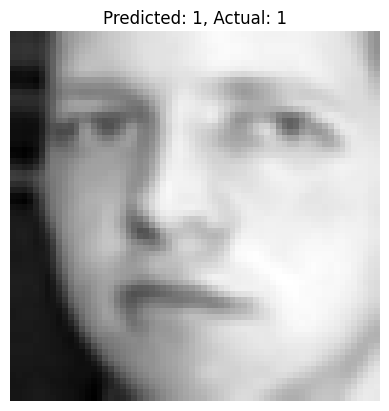

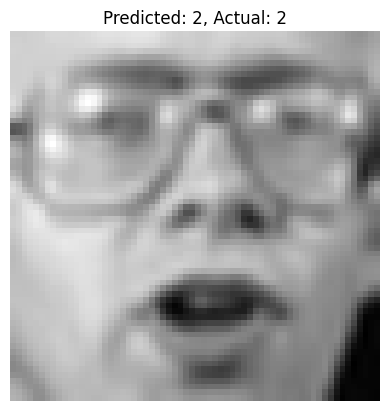

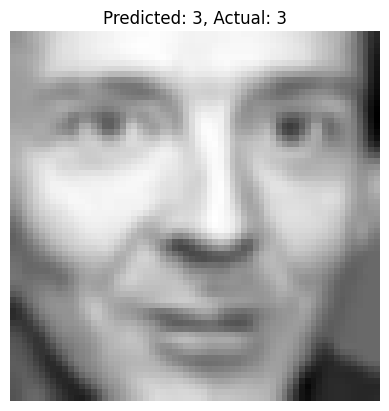

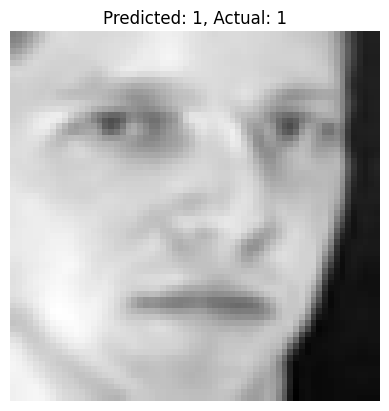

In [ ]:
# Define function to visualize the predictions
def visualize_predictions(model, test_loader, num_images=4):
    model.eval() # Set the model to evaluation mode
    images_shown = 0 # Define images_shown variable

    # Inference process for single image
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            # Show images with predicted labels
            for i in range(len(images)):
                if images_shown >= num_images:
                    return
                img = images[i][0].squeeze(0).cpu()
                plt.imshow(img, cmap='gray')
                plt.title(f"Predicted: {classes[predicted[i].item()]}, Actual: {classes[targets[i].item()]}")
                plt.axis("off")
                plt.show()
                images_shown += 1

# Run visualization
visualize_predictions(model, test_loader)